1

## Packaged needed for this network
### - this will take a while ~7-10 mins
### use python 12.xx
#### these will only be need once after that run cells under 


In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124 -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install opencv-python matplotlib scikit-learn pandas tqdm onnx onnxruntime

  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl (44.0 MB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.3 MB 6.3 MB/s eta 0:00:02
   ---- ----------------------------------- 1.0/9.3 MB 6.3 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/9.3 MB 4.2 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.3 MB 4.7 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.3 MB 4.9 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.3 MB 4.9 MB/s eta 0:00:01
   ------------------------------- -------- 7.3/9.3 MB 5.1 MB/s eta 0:00:01
   ----------------------------------- ---


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


START HERE after cells above has been run once 

In [3]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.notebook import tqdm

check for GPU/CUDA if not then CPU will be used 

In [4]:
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using {DEVICE}")
if torch.cuda.is_available():
     print(f"GPU          : {torch.cuda.get_device_name(0)}")

2.6.0+cu124
False
12.4
using cpu


# PATHS

In [ ]:
# Paths
# put the datasets full path here the script will find the rest
DATASET_ROOT = Path(r"")
OBJECTS_DIR  = DATASET_ROOT / "objects"      # Cropped shapes for training
MASKED_DIR   = DATASET_ROOT / "masked"       # Full scenes for inference testing
LABELS_CSV   = DATASET_ROOT / "labels.csv"

# 5 Real Physical Classes
VALID_CLASSES = ["Circle", "Hexagon", "Square", "Star", "Triangle"]

classes = sorted(VALID_CLASSES)
CLASS_TO_IDX = {name: i for i, name in enumerate(classes)}
IDX_TO_CLASS = {i: name for name, i in CLASS_TO_IDX.items()}

print(f"Active classes ({len(classes)}):")
for idx, name in IDX_TO_CLASS.items():
    print(f"  [{idx}] {name}")

Active classes (5):
  [0] Circle
  [1] Hexagon
  [2] Square
  [3] Star
  [4] Triangle


Collect pairs

In [6]:
#  Collect all valid pairs
samples = []

for folder in OBJECTS_DIR.iterdir():
    if not folder.is_dir() or folder.name not in CLASS_TO_IDX:
        continue  # skip Rectangles, Polygons, etc.

    label_idx = CLASS_TO_IDX[folder.name]
    for img_path in folder.glob("*.png"):
        samples.append((str(img_path), label_idx))

print(f"Clean training dataset: {len(samples)} total images\n")

counts = Counter(IDX_TO_CLASS[idx] for _, idx in samples)
for name, count in sorted(counts.items()):
    print(f"{name:<12} : {count:>3} images")

FileNotFoundError: [WinError 3] Det går inte att hitta sökvägen: 'C:\\Users\\Nils\\Downloads\\dataset\\dataset\\objects'

In [ ]:
paths  = [s[0] for s in samples]
labels  = [s[1] for s in samples]

train_paths,val_paths, train_labels,val_labels = train_test_split(
    paths,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels, # this ensures that all calsses are represented in both sets

)

print(f"Training set   : {len(train_paths)} images")
print(f"Validation set : {len(val_paths)} images")

Training set   : 152 images
Validation set : 38 images


Data augmentation and image transformation

In [ ]:
IMG_SIZE = 128
train_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE,IMG_SIZE)),
    T.RandomRotation(degrees=180),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomAffine(
        degrees=0,
        translate=(0.05,0.05), # small pixel shift
        scale=(0.8,1.1), # slight zoom in and out
    ),
    T.ColorJitter(brightness=0.2,contrast=0.2), # this simulates lighting changes
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456,0.406],  # standard imageNet
                std=[0.299,0.224,0.225]
    ),
])

# Validation Transforms
val_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE,IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

print("Transforms success")

Transforms success


Dataset and dataloader

In [ ]:
class ShapeDataset(Dataset):
    """ loads shape crops from disk and applies OTF transofrmations """
    def __init__(self,paths,labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        # read image with openCV
        img_bgr = cv2.imread(self.paths[idx])
        if img_bgr is None:
            raise FileNotFoundError(f"could not load file : {self.paths[idx]}")

        # covert image to RGB bc torchvision want it
        img_rbg = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # apply the augs from earlier
        if self.transform:
            img_rbg = self.transform(img_rbg)
        labels = torch.tensor(self.labels[idx], dtype=torch.long)
        return img_rbg, labels


# dataset loader
BATCH_SIZE = 16

train_dataset = ShapeDataset(train_paths,
                             train_labels,
                               transform=train_transform
                               )
val_dataset = ShapeDataset(val_paths,
                           val_labels,
                           transform=val_transform
                           )

train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=0
                          )
val_loader = DataLoader(val_dataset,
                        batch_size=BATCH_SIZE,
                        shuffle=True,
                        num_workers=0
                        )



sample_imgs, sample_lbls = next(iter(train_loader))
print(f"Batch image tensor shape: {sample_imgs.shape}  (Batch size, Channels, Height, Width)")
print(f"Batch labels sample:      {sample_lbls.tolist()[:8]}")

Batch image tensor shape: torch.Size([16, 3, 128, 128])  (Batch size, Channels, Height, Width)
Batch labels sample:      [3, 4, 4, 2, 2, 1, 3, 3]


## Model Time MobileNetV3


https://medium.com/@RobuRishabh/understanding-and-implementing-mobilenetv3-422bd0bdfb5a

In [ ]:
def build_model(num_classes:int,freeze_backbone:bool = True) -> nn.Module:
    """
    MobileNetV3, is apperantly cutting-edge architecture for efficient deep learning
    models designed for mobile devices.
    Good for mobile units or arms CPUs
    """
    # load weights
    weights = MobileNet_V3_Small_Weights.IMAGENET1K_V1
    model = mobilenet_v3_small(weights=weights)

    # freze the backbone layers
    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    # replace thr final clasifer layer 1024 features -> num clases
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    return model



model = build_model(num_classes=len(classes), freeze_backbone=True)
model = model.to(DEVICE)
# Check parameter count
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total model parameters    : {total_params:,}")
print(f"Trainable parameters now  : {trainable_params:,}  ({100 * trainable_params / total_params:.2f}%)")
print(f"Model successfully placed on: {DEVICE}")


Total model parameters    : 1,522,981
Trainable parameters now  : 595,973  (39.13%)
Model successfully placed on: cuda


Loss and optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()

def run_epoch(model,loader,is_train:bool, optimizer=None):
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()

    with ctx:
        for imgs,labels in loader:
            imgs,labels = imgs.to(DEVICE), labels.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            logits = model(imgs)
            loss = criterion(logits,labels)

            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item()*imgs.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total



def train_model(model, n_epochs: int, lr: float = 1e-3):
    """Trains the model and saves the best checkpoint based on validation accuracy."""
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    best_acc  = 0.0

    print(f"Starting training for {n_epochs} epochs on {DEVICE}...")
    print("-" * 55)

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, is_train=True, optimizer=optimizer)
        vl_loss, vl_acc = run_epoch(model, val_loader,   is_train=False)

        saved = ""
        if vl_acc > best_acc:
            best_acc = vl_acc
            torch.save(model.state_dict(), "best_shape_cnn.pth")
            saved = "(Saved best checkpoint!)"

        print(f"Epoch [{epoch:02d}/{n_epochs:02d}] | "
              f"Train Acc: {tr_acc * 100:5.1f}% | "
              f"Val Acc: {vl_acc * 100:5.1f}% | "
              f"Val Loss: {vl_loss:.4f} {saved}")
    print("-" * 55)
    print(f"Training Complete! Peak Validation Accuracy: {best_acc * 100:.1f}%")

# run for 15 epochs
train_model(model, n_epochs=50, lr=1e-3)

Starting training for 50 epochs on cuda...
-------------------------------------------------------
Epoch [01/50] | Train Acc:  64.5% | Val Acc:  94.7% | Val Loss: 0.8816 (Saved best checkpoint!)
Epoch [02/50] | Train Acc:  90.8% | Val Acc:  89.5% | Val Loss: 0.5663 
Epoch [03/50] | Train Acc:  94.7% | Val Acc:  89.5% | Val Loss: 0.4587 
Epoch [04/50] | Train Acc:  91.4% | Val Acc:  92.1% | Val Loss: 0.3222 
Epoch [05/50] | Train Acc:  91.4% | Val Acc:  92.1% | Val Loss: 0.2426 
Epoch [06/50] | Train Acc:  96.1% | Val Acc:  97.4% | Val Loss: 0.1843 (Saved best checkpoint!)
Epoch [07/50] | Train Acc:  96.1% | Val Acc:  97.4% | Val Loss: 0.1933 
Epoch [08/50] | Train Acc:  91.4% | Val Acc: 100.0% | Val Loss: 0.1613 (Saved best checkpoint!)
Epoch [09/50] | Train Acc:  94.7% | Val Acc: 100.0% | Val Loss: 0.1283 
Epoch [10/50] | Train Acc:  96.1% | Val Acc:  97.4% | Val Loss: 0.1375 
Epoch [11/50] | Train Acc:  94.1% | Val Acc:  94.7% | Val Loss: 0.1467 
Epoch [12/50] | Train Acc:  94.7% | V

              precision    recall  f1-score   support

      Circle       1.00      1.00      1.00         3
     Hexagon       1.00      1.00      1.00         7
      Square       1.00      1.00      1.00         6
        Star       1.00      1.00      1.00        12
    Triangle       1.00      1.00      1.00        10

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



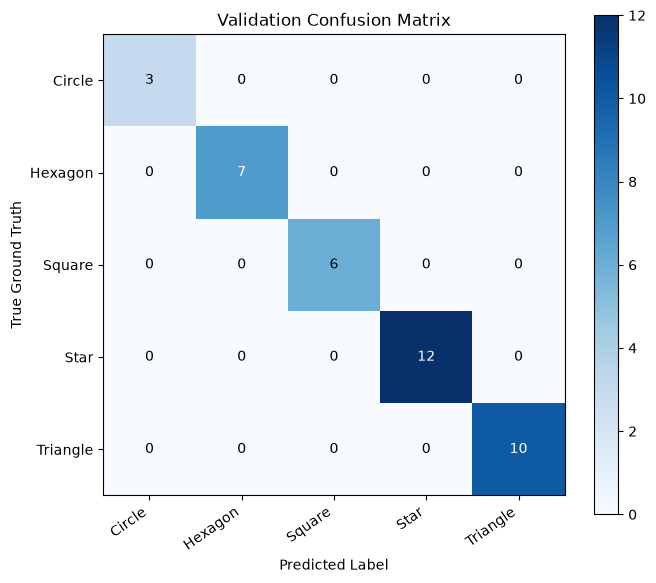

In [ ]:
# ── Load best saved weights ───────────────────────────────────────────────────
model.load_state_dict(torch.load("best_shape_cnn.pth", map_location=DEVICE))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        preds  = logits.argmax(dim=1).cpu().tolist()

        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

# ── Print Precision, Recall, F1 ───────────────────────────────────────────────
print(classification_report(
    all_labels,
    all_preds,
    target_names=classes,
    zero_division=0
))

# ── Plot Visual Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=35, ha="right")
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Ground Truth")
ax.set_title("Validation Confusion Matrix")

# Draw numbers in each cell
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()

In [ ]:
# ── Phase 2: Unfreeze the Backbone ────────────────────────────────────────────
for param in model.features.parameters():
    param.requires_grad = True

trainable_after = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters now: {trainable_after:,} (100% of network is learning!)")

# ── Fine-tune with a gentle learning rate (1e-4) for 15 epochs ───────────────
train_model(model, n_epochs=15, lr=1e-4)

Trainable parameters now: 1,522,981 (100% of network is learning!)
Starting training for 15 epochs on cuda...
-------------------------------------------------------
Epoch [01/15] | Train Acc:  97.4% | Val Acc: 100.0% | Val Loss: 0.1136 (Saved best checkpoint!)
Epoch [02/15] | Train Acc:  98.0% | Val Acc: 100.0% | Val Loss: 0.0682 
Epoch [03/15] | Train Acc:  95.4% | Val Acc: 100.0% | Val Loss: 0.0538 
Epoch [04/15] | Train Acc:  98.0% | Val Acc: 100.0% | Val Loss: 0.0429 
Epoch [05/15] | Train Acc:  96.7% | Val Acc: 100.0% | Val Loss: 0.0364 
Epoch [06/15] | Train Acc:  98.7% | Val Acc: 100.0% | Val Loss: 0.0336 
Epoch [07/15] | Train Acc:  97.4% | Val Acc: 100.0% | Val Loss: 0.0317 
Epoch [08/15] | Train Acc:  99.3% | Val Acc: 100.0% | Val Loss: 0.0257 
Epoch [09/15] | Train Acc:  98.7% | Val Acc: 100.0% | Val Loss: 0.0223 
Epoch [10/15] | Train Acc:  98.7% | Val Acc: 100.0% | Val Loss: 0.0222 
Epoch [11/15] | Train Acc: 100.0% | Val Acc: 100.0% | Val Loss: 0.0262 
Epoch [12/15] | Tr

              precision    recall  f1-score   support

      Circle       1.00      1.00      1.00         3
     Hexagon       1.00      1.00      1.00         7
      Square       1.00      1.00      1.00         6
        Star       1.00      1.00      1.00        12
    Triangle       1.00      1.00      1.00        10

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



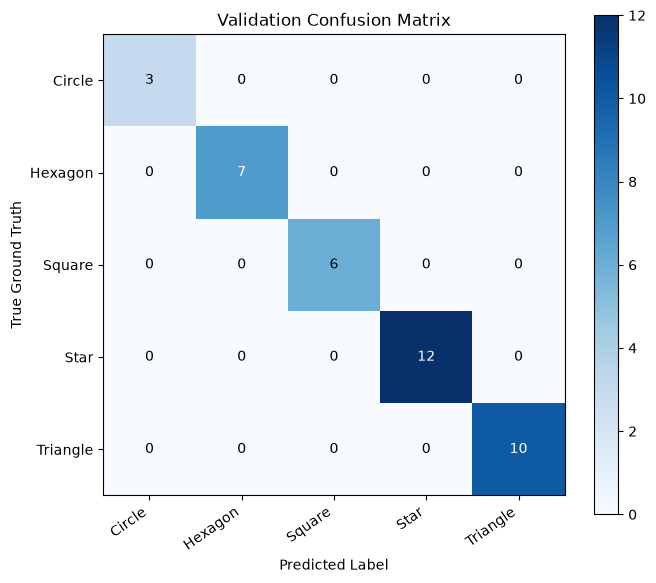

In [ ]:
# Load best saved weights
model.load_state_dict(torch.load("best_shape_cnn.pth", map_location=DEVICE))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        preds  = logits.argmax(dim=1).cpu().tolist()

        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

#  Print Precision, Recall, F1
print(classification_report(
    all_labels,
    all_preds,
    target_names=classes,
    zero_division=0
))

# Plot Visual Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=35, ha="right")
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Ground Truth")
ax.set_title("Validation Confusion Matrix")

# Draw numbers
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()

In [ ]:
def detect_shape_regions(
    img_bgr: np.ndarray,
    min_area: int = 2500,       # Ignore tiny noise / dust
    max_area: int = 25000,      # Anything bigger is a CLUSTER of multiple pieces!
    max_perimeter: int = 800,   # Single piece perimeter limit
    threshold: int = 25,
    pad: int = 10
):
    """
    Finds isolated single-piece contours and centroids.
    - Rejects boundary cut-off pieces
    - Rejects clusters/jams where multiple shapes touch
    """
    H, W = img_bgr.shape[:2]
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    regions = []
    for cnt in contours:
        area  = cv2.contourArea(cnt)
        perim = cv2.arcLength(cnt, True)

        # Reject noise
        if area < min_area:
            continue

        x, y, w, h = cv2.boundingRect(cnt)

        # Reject frame border cutoffs
        if x <= 2 or y <= 2 or (x + w) >= (W - 2) or (y + h) >= (H - 2):
            continue

        # Reject CLUSTERS (multiple touching shapes)
        if area > max_area or perim > max_perimeter:
            # print(f"Ignored cluster: Area={area:.0f}px, Perim={perim:.0f}px")
            continue

        # Add padding around crop
        x0 = max(0, x - pad)
        y0 = max(0, y - pad)
        x1 = min(W, x + w + pad)
        y1 = min(H, y + h + pad)
        roi = img_bgr[y0:y1, x0:x1].copy()

        # Centroid
        M = cv2.moments(cnt)
        cx = int(M["m10"] / M["m00"]) if M["m00"] != 0 else x + w // 2
        cy = int(M["m01"] / M["m00"]) if M["m00"] != 0 else y + h // 2

        regions.append({
            "contour": cnt,
            "bbox": (x, y, w, h),
            "roi": roi,
            "centroid": (cx, cy),
            "area": area,
        })

    return regions

In [ ]:
@torch.no_grad()
def classify_roi(roi_bgr: np.ndarray, model: nn.Module) -> tuple[str, float]:
    """
    Takes a single shape crop, runs it through the CNN,
    and returns (class_name, confidence).
    """
    # Convert OpenCV BGR to RGB
    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)

    #  Apply validation transform (resize to 128x128 + normalize)
    tensor = val_transform(roi_rgb).unsqueeze(0).to(DEVICE)  # Shape: (1, 3, 128, 128)

    # Model forward pass
    logits = model(tensor)
    probs  = torch.softmax(logits, dim=1)[0]

    pred_idx   = probs.argmax().item()
    confidence = probs[pred_idx].item()
    class_name = IDX_TO_CLASS[pred_idx]

    return class_name, confidence

print("classify_roi function defined!")

classify_roi function defined!


In [ ]:
# Color Palette for Drawing (BGR format)
CLASS_COLORS = {
    "Circle":   (0, 215, 255),   # Gold / Yellow
    "Hexagon":  (255, 0, 255),   # Magenta
    "Square":   (255, 255, 0),   # Cyan
    "Star":     (0, 140, 255),   # Orange
    "Triangle": (0, 255, 0),     # Bright Green
}

def annotate_scene(scene_path: str, model: nn.Module):
    """Detects, classifies, and annotates every shape in a full scene."""
    img_bgr   = cv2.imread(scene_path)
    annotated = img_bgr.copy()
    regions   = detect_shape_regions(img_bgr)

    detections = []

    for region in regions:
        roi = region["roi"]
        class_name, conf = classify_roi(roi, model)
        cx, cy = region["centroid"]

        color = CLASS_COLORS.get(class_name, (255, 255, 255))

        # Draw the exact contour outline
        cv2.drawContours(annotated, [region["contour"]], -1, color, 2)

        # Draw a small target circle at the centroid SUCC point
        cv2.circle(annotated, (cx, cy), 5, (0, 0, 255), -1)

        # Draw text badge
        label = f"{class_name} {conf * 100:.0f}%"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(annotated, (cx - tw//2 - 3, cy - th - 10), (cx + tw//2 + 3, cy - 4), color, -1)
        cv2.putText(annotated, label, (cx - tw//2, cy - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)

        detections.append({
            "class": class_name,
            "confidence": conf,
            "centroid_px": (cx, cy),
            "area": region["area"],
        })

    return annotated, detections



Processing 23 test scenes...


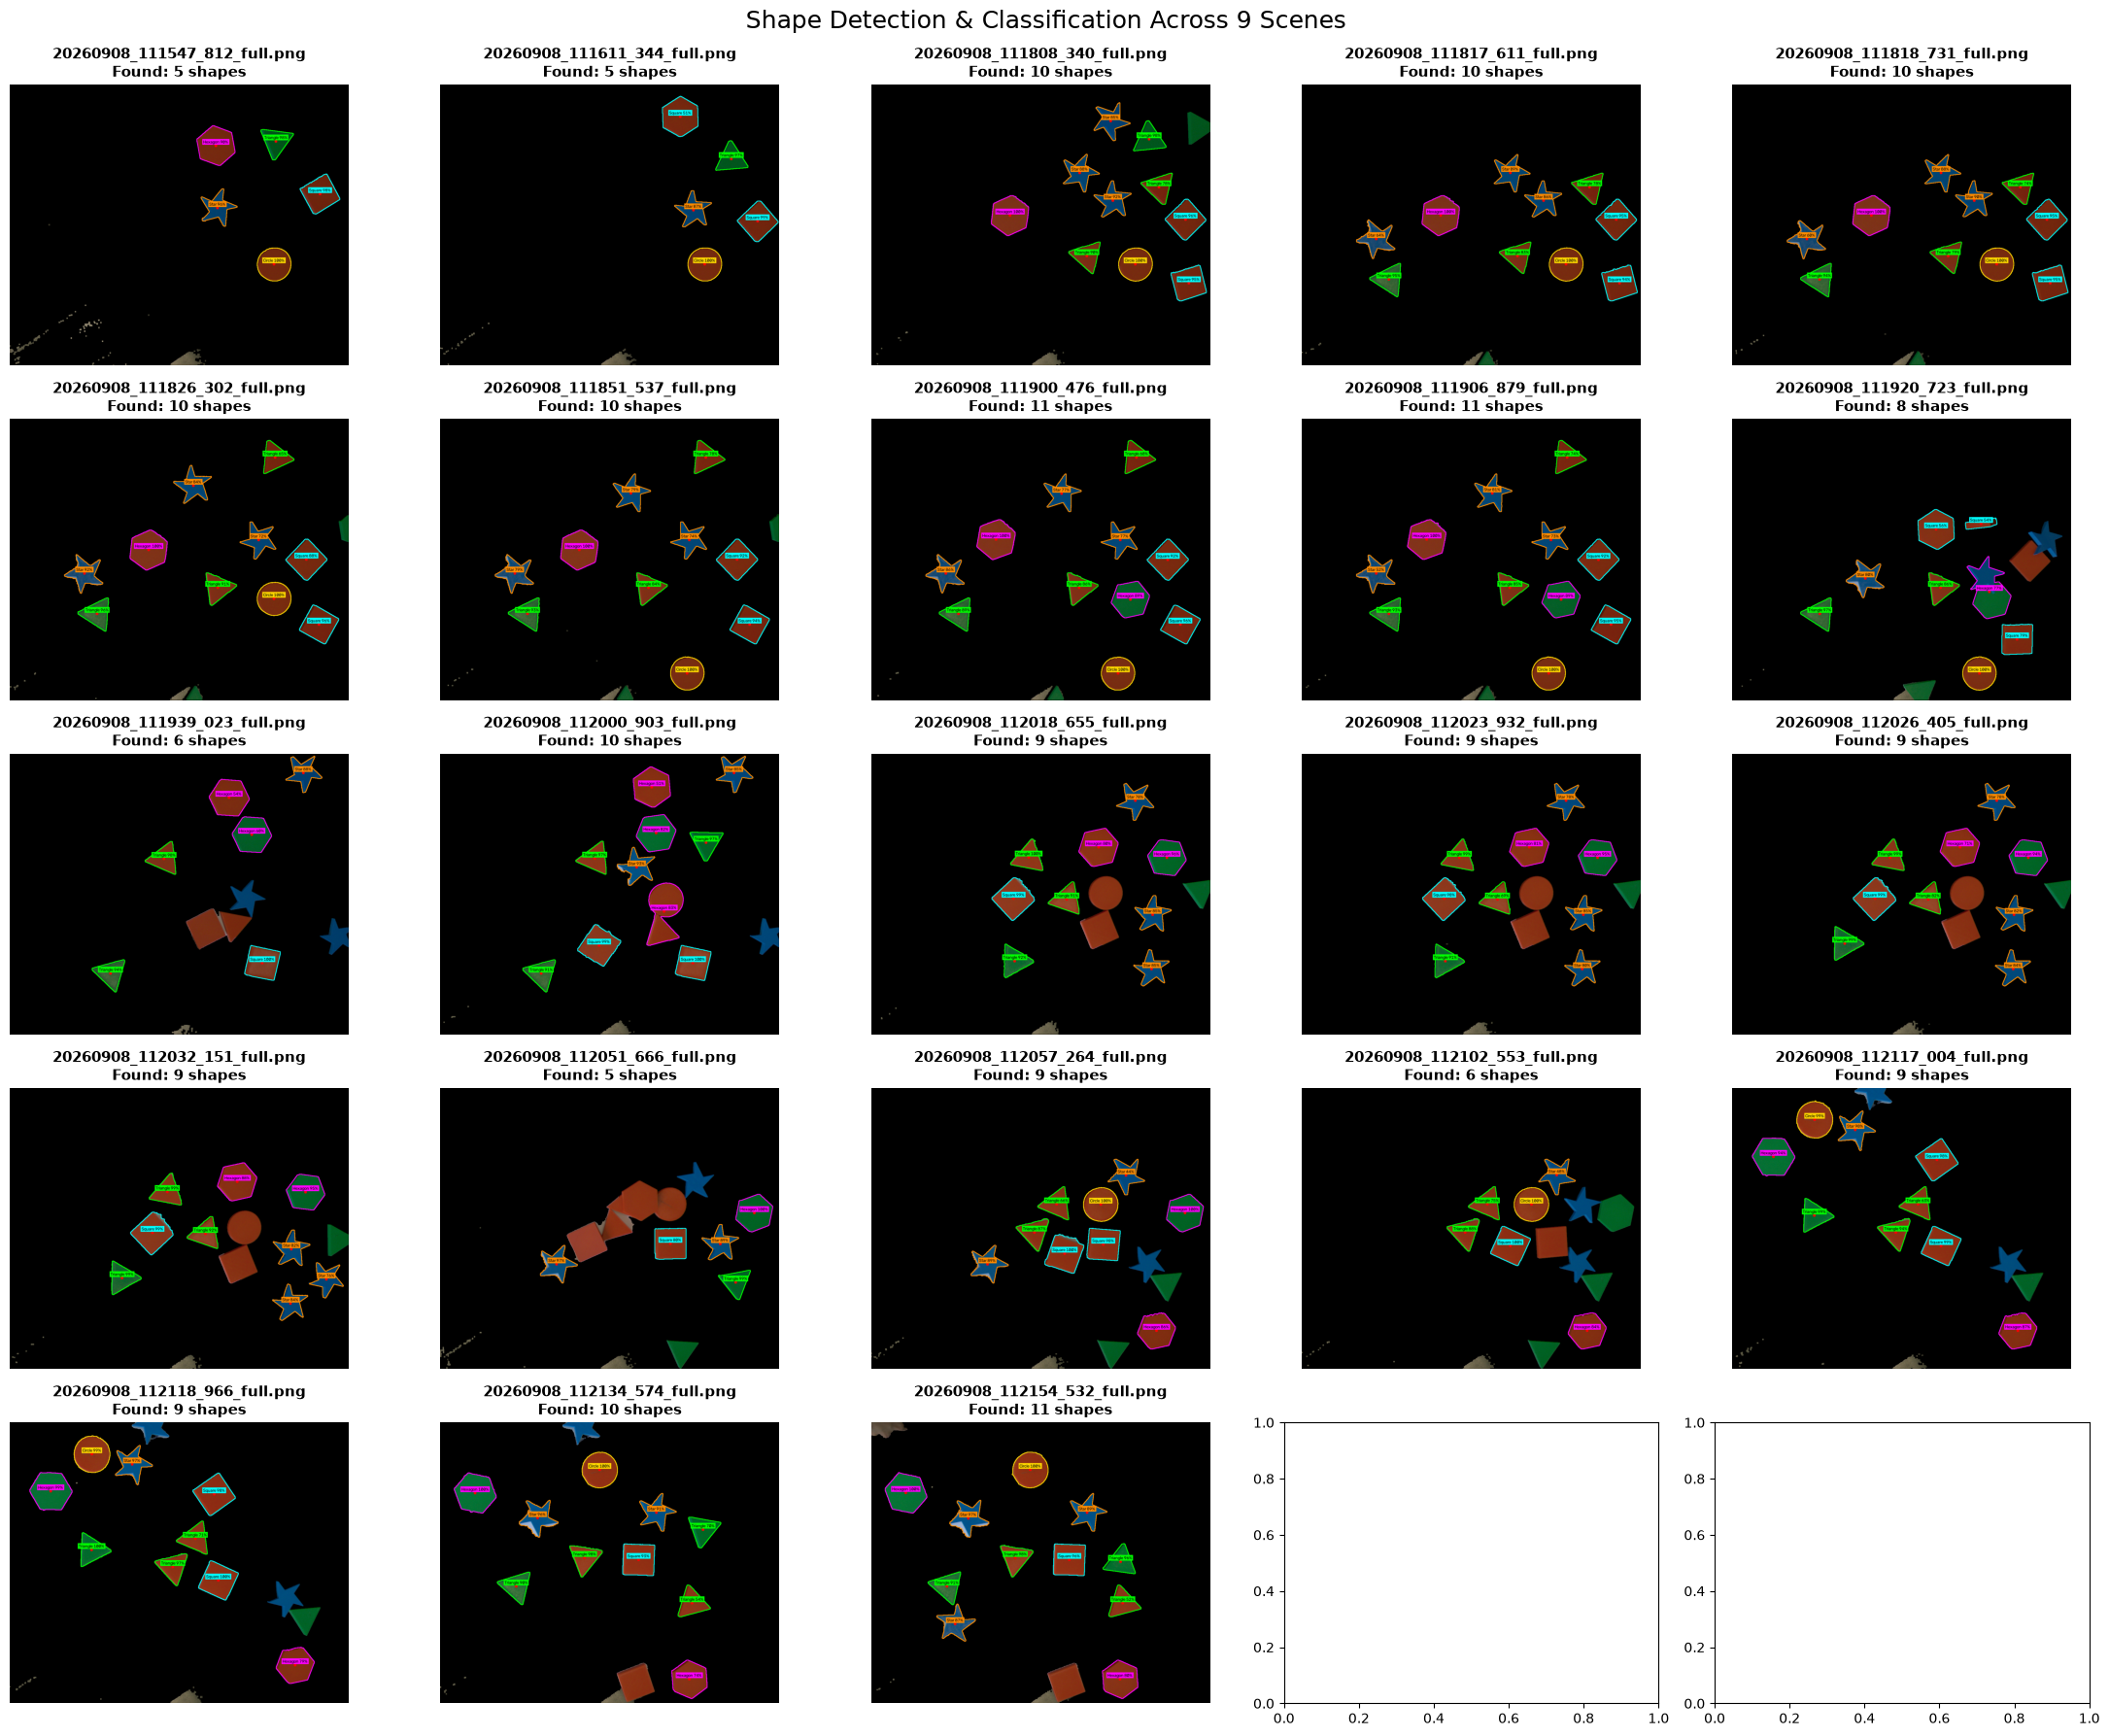

In [ ]:
scene_paths = sorted(list(MASKED_DIR.glob("*.png")))[:23]

fig, axes = plt.subplots(5, 5, figsize=(22, 18))
axes = axes.flatten()

print(f"Processing {len(scene_paths)} test scenes...")

for i, scene_path in enumerate(scene_paths):
    annotated, dets = annotate_scene(str(scene_path), model)

    # Display in 3x3 grid
    axes[i].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"{scene_path.name}\nFound: {len(dets)} shapes", fontsize=11, fontweight="bold")
    axes[i].axis("off")

plt.suptitle("Shape Detection & Classification Across 9 Scenes", fontsize=18, y=0.99)
plt.tight_layout()
plt.show()